# ARTI 403 – Image Processing
## Lab 1 — Basics of Programming with Python

**Student name:** Ahmed Albuainain
**Student ID:** 2240006128
**Section:** 7MA1
**Date:** 6 September 2026

---

### Outcome #1
Explain how digital images are represented and manipulated in a computer.

### Contents
| Task | Description |
|---|---|
| Task 0 | Environment check and preparing the `images/` folder |
| Task 0b | The scikit-image general-purpose image dataset (course resource) |
| Task 1 | Python & NumPy practice (cheat-sheet exercises) |
| Task 2 | Loading and visualizing images (OpenCV and PIL) |
| Task 3 | Saving images to disk |
| Task 4 | Displaying an image as a NumPy array |
| Task 5 | Assessment — NumPy operations on the image array |

---
## Task 0 — Environment check

Run this cell first. It prints the version of every library required by the lab
(NumPy, OpenCV, scikit-image, Pillow, Matplotlib) so we know the environment is ready.

If a library is missing, install it once from a notebook cell with:
`!pip install numpy opencv-python scikit-image pillow matplotlib`

In [34]:
import sys
import numpy as np
import cv2
import skimage as ski
import PIL
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm

print("Python      :", sys.version.split()[0])
print("NumPy       :", np.__version__)
print("OpenCV      :", cv2.__version__)
print("scikit-image:", ski.__version__)
print("Pillow      :", PIL.__version__)
print("Matplotlib  :", matplotlib.__version__)

# show plots inside the notebook
%matplotlib inline

Python      : 3.13.5
NumPy       : 2.3.5
OpenCV      : 5.0.0
scikit-image: 0.26.0
Pillow      : 12.1.0
Matplotlib  : 3.10.8


### Preparing the `images/` folder

The lab manual reads images from a folder called `images/`. We build that folder from the
sample images provided in the course resource,
the [scikit-image general-purpose images gallery](https://scikit-image.org/docs/stable/auto_examples/data/plot_general.html)
(the full set is explored in Task 0b below).

* `images/cameraman.tif` — the classic *cameraman* test image, from `skimage.data.camera()`
* `images/gray_256.tif` — a 256x256 grayscale image, from `skimage.data.coins()`

If the folder already contains these files, they are kept and nothing is overwritten.

In [35]:
import os
from PIL import Image
from skimage.transform import resize
from skimage.util import img_as_ubyte

os.makedirs("images", exist_ok=True)
os.makedirs("output", exist_ok=True)

# 1) cameraman.tif  -> 512x512 grayscale
if not os.path.exists("images/cameraman.tif"):
    Image.fromarray(ski.data.camera()).save("images/cameraman.tif")

# 2) gray_256.tif   -> 256x256 grayscale
if not os.path.exists("images/gray_256.tif"):
    gray256 = img_as_ubyte(resize(ski.data.coins(), (256, 256), anti_aliasing=True))
    Image.fromarray(gray256).save("images/gray_256.tif")

print("Files in images/ :", sorted(os.listdir("images")))

Files in images/ : ['cameraman.tif', 'gray_256.tif']


---
## Task 0b — The scikit-image general-purpose image dataset

Course resource: <https://scikit-image.org/docs/stable/auto_examples/data/plot_general.html>

`skimage.data` ships with a set of ready-to-use test images. They are the standard images used
in image-processing courses and papers, and they are the source of the files we prepared above.

Two things are worth noticing while looking at them:

* **Grayscale images are 2-D arrays** with shape `(height, width)`, so they need
  `cmap=plt.cm.gray` to be displayed correctly.
* **Colour images are 3-D arrays** with shape `(height, width, 3)` and are displayed as they are.

The `if image.ndim == 2` test in the code below is exactly this distinction — the number of
array dimensions is what tells us whether an image is grayscale or colour.

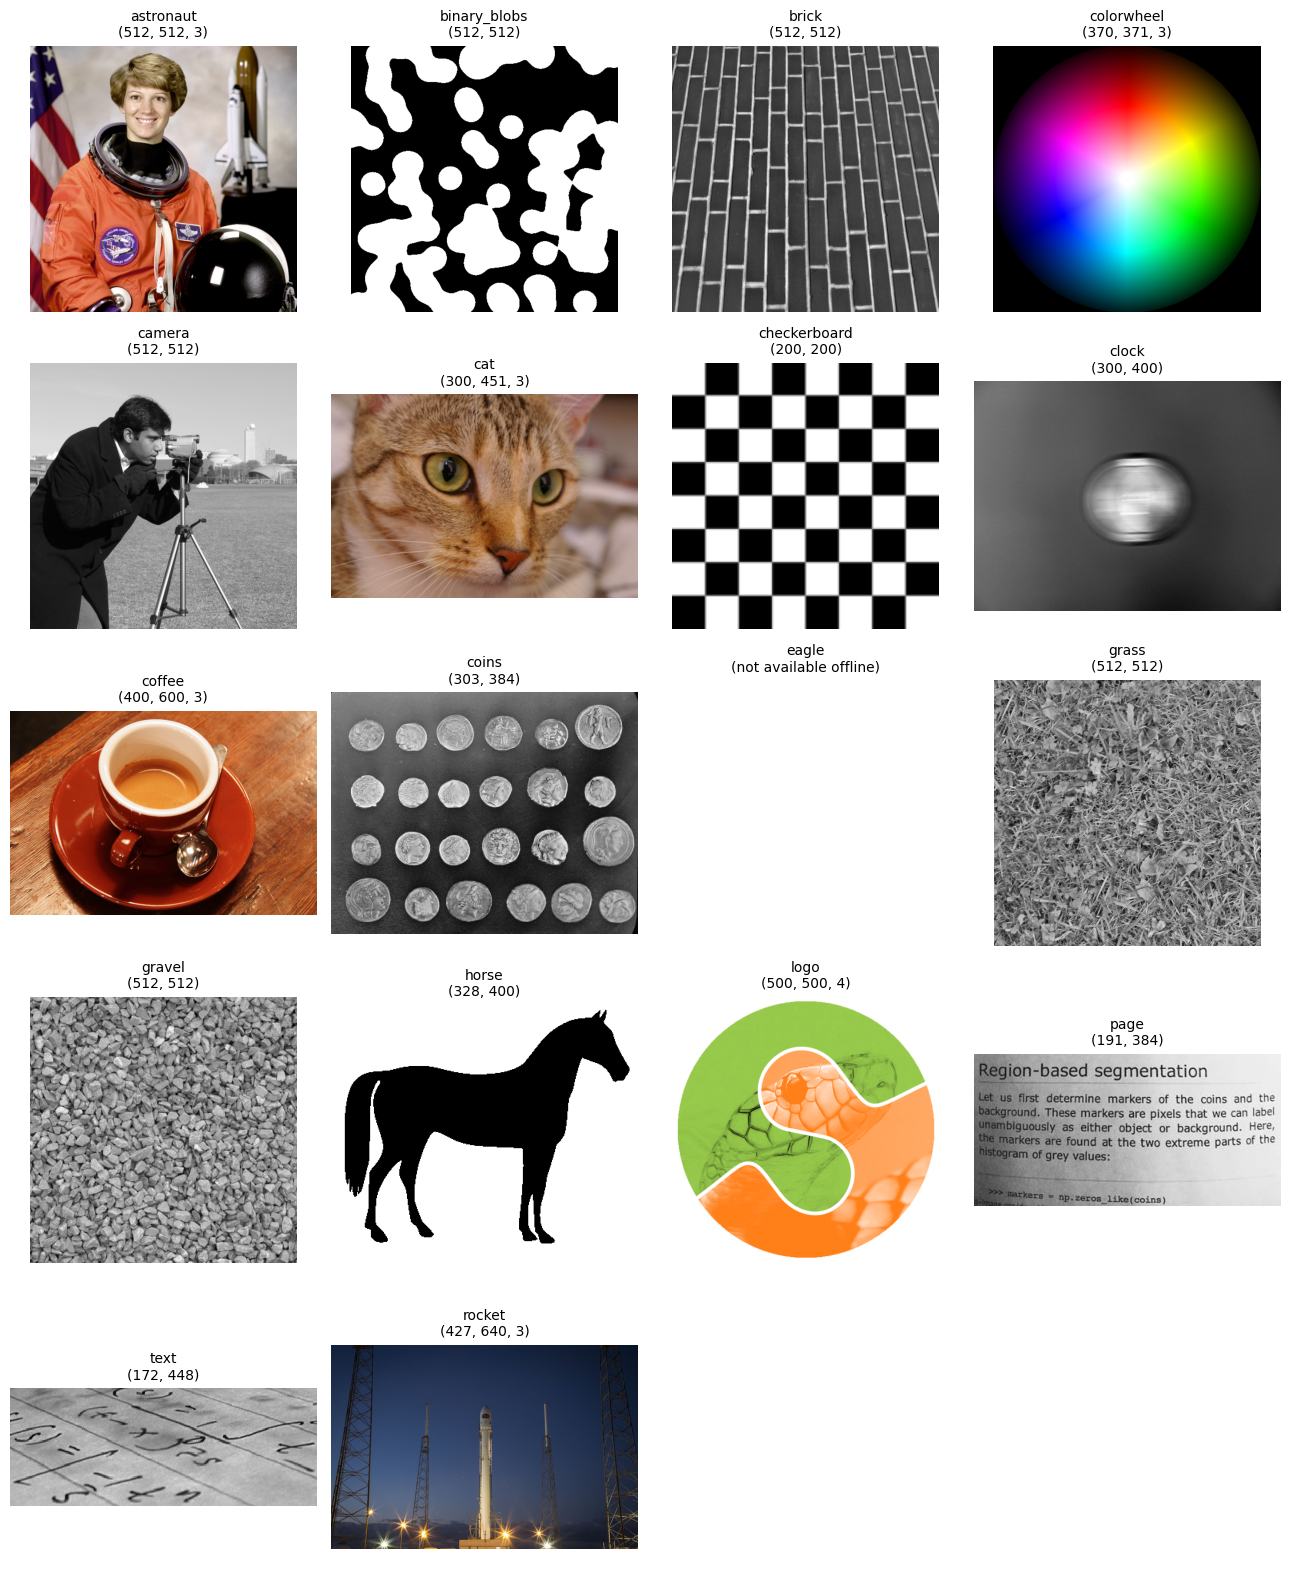

In [36]:
images = (
    'astronaut', 'binary_blobs', 'brick', 'colorwheel',
    'camera', 'cat', 'checkerboard', 'clock',
    'coffee', 'coins', 'eagle', 'grass',
    'gravel', 'horse', 'logo', 'page',
    'text', 'rocket',
)

fig, axes = plt.subplots(5, 4, figsize=(13, 16))
for ax_, name in zip(axes.flat, images):
    ax_.axis('off')
    try:
        caller = getattr(ski.data, name)     # look the function up by its name
        image = caller()                     # call it to get the image array
    except Exception:
        # a few samples are downloaded on demand and need the optional
        # 'pooch' package plus an internet connection
        ax_.set_title(f"{name}\n(not available offline)", fontsize=10)
        continue
    if image.ndim == 2:                      # 2-D  -> grayscale
        ax_.imshow(image, cmap=plt.cm.gray)
    else:                                    # 3-D  -> colour
        ax_.imshow(image)
    ax_.set_title(f"{name}\n{image.shape}", fontsize=10)

for ax_ in axes.flat[len(images):]:          # hide the unused cells of the grid
    ax_.axis('off')

plt.tight_layout()
plt.show()

### Comparing the arrays behind these images

The same information as a table: shape, number of dimensions, data type and value range.
Every one of these images is nothing more than an array of integers.

In [37]:
print(f"{'name':<14}{'shape':<20}{'ndim':<7}{'dtype':<10}{'min':<7}{'max':<7}{'kind'}")
print("-" * 78)
for name in images:
    try:
        im = getattr(ski.data, name)()
    except Exception:
        print(f"{name:<14}(needs the optional 'pooch' package + internet)")
        continue
    kind = "grayscale" if im.ndim == 2 else "colour"
    print(f"{name:<14}{str(im.shape):<20}{im.ndim:<7}{str(im.dtype):<10}"
          f"{str(im.min()):<7}{str(im.max()):<7}{kind}")

name          shape               ndim   dtype     min    max    kind
------------------------------------------------------------------------------
astronaut     (512, 512, 3)       3      uint8     0      255    colour
binary_blobs  (512, 512)          2      bool      False  True   grayscale
brick         (512, 512)          2      uint8     63     207    grayscale
colorwheel    (370, 371, 3)       3      uint8     0      255    colour
camera        (512, 512)          2      uint8     0      255    grayscale
cat           (300, 451, 3)       3      uint8     0      231    colour
checkerboard  (200, 200)          2      uint8     0      255    grayscale
clock         (300, 400)          2      uint8     99     247    grayscale
coffee        (400, 600, 3)       3      uint8     0      255    colour
coins         (303, 384)          2      uint8     1      252    grayscale
eagle         (needs the optional 'pooch' package + internet)
grass         (512, 512)          2      uint8     

### Building an image from scratch with NumPy

The course resource ends with a second figure that mixes samples from `skimage.data` with an
image that is **not loaded from anywhere** — it is created directly as an array:

```python
further_img = np.full((300, 300), 255)
for xpos in [100, 150, 200]:
    further_img[150 - 10 : 150 + 10, xpos - 10 : xpos + 10] = 0
```

`np.full((300, 300), 255)` makes a 300x300 white canvas, and each slice assignment sets a
20x20 block of pixels to 0, which draws a black square. No image file and no image-processing
function are involved — an image really is just an array of numbers.

shape: (300, 300) | dtype: int64
unique values: [  0 255]


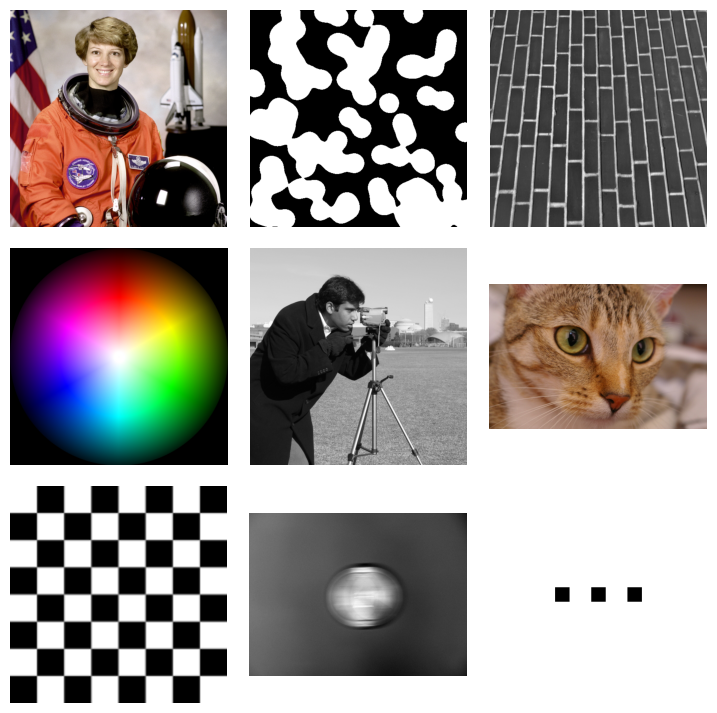

In [38]:
further_img = np.full((300, 300), 255)
for xpos in [100, 150, 200]:
    further_img[150 - 10 : 150 + 10, xpos - 10 : xpos + 10] = 0

print("shape:", further_img.shape, "| dtype:", further_img.dtype)
print("unique values:", np.unique(further_img))     # only 0 (black) and 255 (white)

fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(9, 9))
for ax_ in axs.flat:
    ax_.axis("off")
axs[0, 0].imshow(ski.data.astronaut())
axs[0, 1].imshow(ski.data.binary_blobs(), cmap=plt.cm.gray)
axs[0, 2].imshow(ski.data.brick(), cmap=plt.cm.gray)
axs[1, 0].imshow(ski.data.colorwheel())
axs[1, 1].imshow(ski.data.camera(), cmap=plt.cm.gray)
axs[1, 2].imshow(ski.data.cat())
axs[2, 0].imshow(ski.data.checkerboard(), cmap=plt.cm.gray)
axs[2, 1].imshow(ski.data.clock(), cmap=plt.cm.gray)
axs[2, 2].imshow(further_img, cmap=plt.cm.gray)
plt.subplots_adjust(wspace=0.1, hspace=0.1)
plt.show()

Extending the same idea: a few more shapes drawn on a blank canvas using nothing but
slicing, boolean masks and arithmetic.

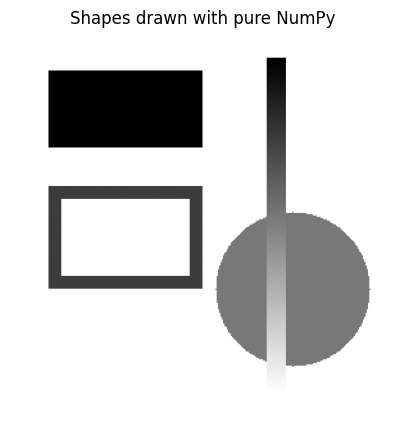

shape: (300, 300) | dtype: uint8 | distinct grey levels: 256


In [39]:
canvas = np.full((300, 300), 255, dtype=np.uint8)

# a filled rectangle: direct slice assignment
canvas[30:90, 30:150] = 0

# a hollow rectangle: draw the filled shape, then clear the inside
canvas[120:200, 30:150] = 60
canvas[130:190, 40:140] = 255

# a circle: a boolean mask built from the coordinate grid
rows, cols = np.ogrid[:300, :300]
circle = (rows - 200) ** 2 + (cols - 220) ** 2 <= 60 ** 2
canvas[circle] = 120

# a diagonal gradient strip: arithmetic on the coordinates
canvas[20:280, 200:215] = ((rows[20:280] - 20) * 255 // 260).astype(np.uint8)

plt.figure(figsize=(5, 5))
plt.imshow(canvas, cmap='gray', vmin=0, vmax=255)
plt.title("Shapes drawn with pure NumPy")
plt.axis('off')
plt.show()

print("shape:", canvas.shape, "| dtype:", canvas.dtype,
      "| distinct grey levels:", len(np.unique(canvas)))

---
## Task 1 — Exercise with the Python / NumPy cheat sheets

Everything below follows the *NumPy Basics* cheat sheet section by section.
This matters because **a digital image is nothing more than a NumPy array**, so every
operation practised here is an operation we can later apply to an image.

### 1.1 Creating arrays

In [40]:
import numpy as np

a = np.array([1, 2, 3])                                   # 1-D array
b = np.array([(1.5, 2, 3), (4, 5, 6)], dtype=float)       # 2-D array
c = np.array([[(1.5, 2, 3), (4, 5, 6)],
              [(3, 2, 1), (4, 5, 6)]], dtype=float)       # 3-D array

print("a =", a)
print("b =\n", b)
print("c shape =", c.shape)

a = [1 2 3]
b =
 [[1.5 2.  3. ]
 [4.  5.  6. ]]
c shape = (2, 2, 3)


### 1.2 Initial placeholders

In [41]:
print("zeros:\n",   np.zeros((3, 4)))
print("ones:\n",    np.ones((2, 3), dtype=np.int16))
print("arange:",     np.arange(10, 25, 5))       # step value
print("linspace:",   np.linspace(0, 2, 9))       # number of samples
print("full:\n",    np.full((2, 2), 7))         # constant array
print("eye:\n",     np.eye(2))                  # identity matrix
print("random:\n",  np.random.random((2, 2)))

zeros:
 [[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
ones:
 [[1 1 1]
 [1 1 1]]
arange: [10 15 20]
linspace: [0.   0.25 0.5  0.75 1.   1.25 1.5  1.75 2.  ]
full:
 [[7 7]
 [7 7]]
eye:
 [[1. 0.]
 [0. 1.]]
random:
 [[0.67295491 0.04456319]
 [0.96132967 0.98358176]]


### 1.3 Inspecting an array

These five attributes are the ones we will read off an image in Task 4.

In [42]:
print("a.shape      :", a.shape)        # dimensions
print("len(a)       :", len(a))         # length
print("b.ndim       :", b.ndim)         # number of dimensions
print("b.size       :", b.size)         # number of elements
print("b.dtype      :", b.dtype)        # data type
print("b.astype(int):\n", b.astype(int))

a.shape      : (3,)
len(a)       : 3
b.ndim       : 2
b.size       : 6
b.dtype      : float64
b.astype(int):
 [[1 2 3]
 [4 5 6]]


### 1.4 Arithmetic operations

All arithmetic in NumPy is **element-wise**, which is what makes image maths so short to write.

In [43]:
print("b - a =\n", b - a)
print("b + a =\n", np.add(b, a))
print("b * a =\n", np.multiply(b, a))
print("b / a =\n", np.divide(b, a))
print("sqrt(b) =\n", np.sqrt(b))
print("exp(a)  =", np.exp(a))
print("dot     =\n", np.full((2, 2), 7).dot(np.eye(2)))

b - a =
 [[0.5 0.  0. ]
 [3.  3.  3. ]]
b + a =
 [[2.5 4.  6. ]
 [5.  7.  9. ]]
b * a =
 [[ 1.5  4.   9. ]
 [ 4.  10.  18. ]]
b / a =
 [[1.5 1.  1. ]
 [4.  2.5 2. ]]
sqrt(b) =
 [[1.22474487 1.41421356 1.73205081]
 [2.         2.23606798 2.44948974]]
exp(a)  = [ 2.71828183  7.3890561  20.08553692]
dot     =
 [[7. 7.]
 [7. 7.]]


### 1.5 Aggregate functions

In [44]:
print("sum        :", a.sum())
print("min        :", a.min())
print("max(axis=0):", b.max(axis=0))
print("cumsum     :\n", b.cumsum(axis=1))
print("mean       :", a.mean())
print("median     :", np.median(b))
print("std        :", np.std(b))

sum        : 6
min        : 1
max(axis=0): [4. 5. 6.]
cumsum     :
 [[ 1.5  3.5  6.5]
 [ 4.   9.  15. ]]
mean       : 2.0
median     : 3.5
std        : 1.5920810978785667


### 1.6 Subsetting, slicing and indexing

Slicing is how we crop an image, and boolean indexing is how we threshold one.

In [45]:
print("a[2]        :", a[2])          # single element
print("b[1, 2]     :", b[1, 2])       # row 1, column 2
print("a[0:2]      :", a[0:2])        # slice
print("b[0:2, 1]   :", b[0:2, 1])     # column slice
print("b[:1]       :", b[:1])         # first row
print("a[::-1]     :", a[::-1])       # reversed
print("a[a < 2]    :", a[a < 2])      # boolean indexing
print("fancy index :", b[[1, 0, 1, 0], [0, 1, 2, 0]])

a[2]        : 3
b[1, 2]     : 6.0
a[0:2]      : [1 2]
b[0:2, 1]   : [2. 5.]
b[:1]       : [[1.5 2.  3. ]]
a[::-1]     : [3 2 1]
a[a < 2]    : [1]
fancy index : [4.  2.  6.  1.5]


### 1.7 Array manipulation

In [46]:
print("transpose:\n", np.transpose(b))
print("ravel    :",  b.ravel())                 # flatten
print("reshape  :\n", b.reshape(3, 2))
print("concat   :",  np.concatenate((a, np.array([10, 15, 20]))))
print("vstack   :\n", np.vstack((a, b)))
print("hstack   :\n", np.hstack((np.eye(2), np.full((2, 2), 7))))
print("hsplit   :",  np.hsplit(a, 3))

transpose:
 [[1.5 4. ]
 [2.  5. ]
 [3.  6. ]]
ravel    : [1.5 2.  3.  4.  5.  6. ]
reshape  :
 [[1.5 2. ]
 [3.  4. ]
 [5.  6. ]]
concat   : [ 1  2  3 10 15 20]
vstack   :
 [[1.  2.  3. ]
 [1.5 2.  3. ]
 [4.  5.  6. ]]
hstack   :
 [[1. 0. 7. 7.]
 [0. 1. 7. 7.]]
hsplit   : [array([1]), array([2]), array([3])]


---
## Task 2 — Loading and visualizing images

### 2.1 Loading with OpenCV

`cv2.imread()` returns the pixel data directly as a NumPy array.

**Important:** OpenCV stores colour channels in **BGR** order, while Matplotlib expects **RGB**.
Displaying an OpenCV image without converting it produces wrong colours, so we show both
versions side by side to make the difference visible.

type : <class 'numpy.ndarray'>
shape: (512, 512, 3)


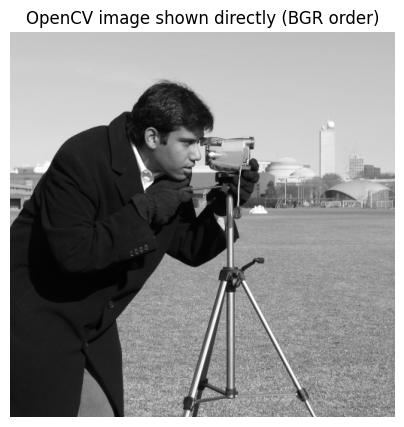

In [47]:
import cv2

img = cv2.imread('images/cameraman.tif')   # load the image data into a NumPy array
print("type :", type(img))
print("shape:", img.shape)

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title("OpenCV image shown directly (BGR order)")
plt.axis('off')
plt.show()

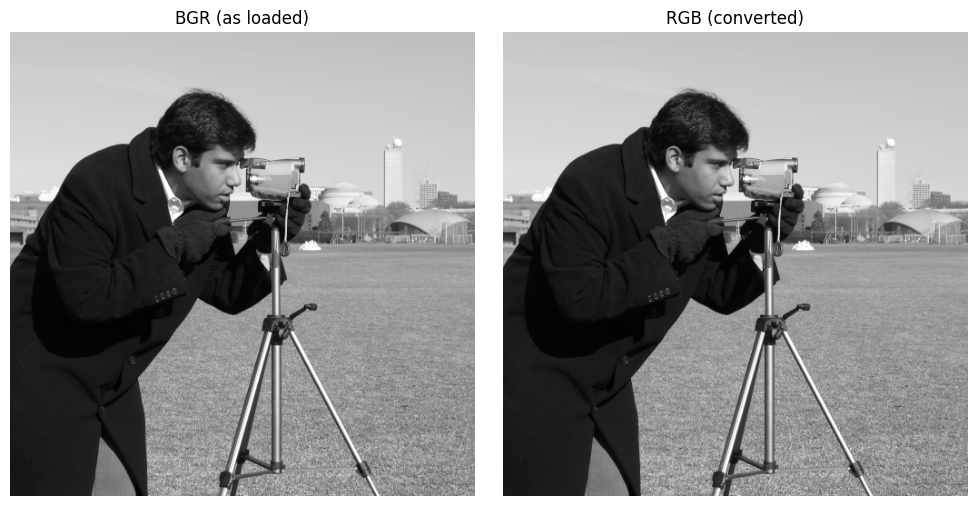

In [48]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)   # convert BGR -> RGB

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img);     ax[0].set_title("BGR (as loaded)");  ax[0].axis('off')
ax[1].imshow(img_rgb); ax[1].set_title("RGB (converted)");  ax[1].axis('off')
plt.tight_layout()
plt.show()

### 2.2 Loading with PIL (Pillow)

`Image.open()` returns a PIL **Image object**, not an array. It is displayed with a grayscale
colormap (`cm.Greys_r`) because the file is a single-channel grayscale image.

mode : L
size : (256, 256)


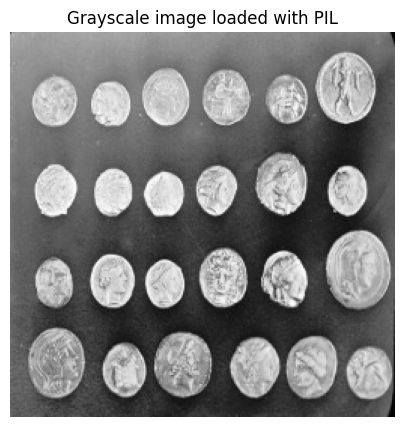

In [49]:
from PIL import Image

img2 = Image.open('images/gray_256.tif')   # load image into a PIL Image object
print("mode :", img2.mode)     # 'L' = 8-bit grayscale
print("size :", img2.size)     # (width, height)

plt.figure(figsize=(5, 5))
plt.imshow(img2, cmap=cm.Greys_r)
plt.title("Grayscale image loaded with PIL")
plt.axis('off')
plt.show()

### 2.3 OpenCV vs PIL — summary

| | OpenCV (`cv2`) | PIL (`Pillow`) |
|---|---|---|
| Returned object | NumPy array | PIL `Image` object |
| Channel order | BGR | RGB |
| Shape / size | `img.shape` = (height, width, channels) | `img.size` = (width, height) |
| Convert to array | already an array | `np.array(img2)` |

---
## Task 3 — Image storing

Saving the same picture in two ways. Note that the source files are `.tif` (lossless) while we
write `.jpg` (lossy compression), which is why the saved files are much smaller.

In [50]:
# Saving an image to disk using OpenCV
ok = cv2.imwrite('output/new_image.jpg', img)
print("OpenCV save succeeded:", ok)

# Saving an image to disk using PIL
img2.save('output/new_image2.jpg')
print("PIL save done")

for f in ['output/new_image.jpg', 'output/new_image2.jpg']:
    print(f, "->", os.path.getsize(f), "bytes")

OpenCV save succeeded: True
PIL save done
output/new_image.jpg -> 86612 bytes
output/new_image2.jpg -> 12328 bytes


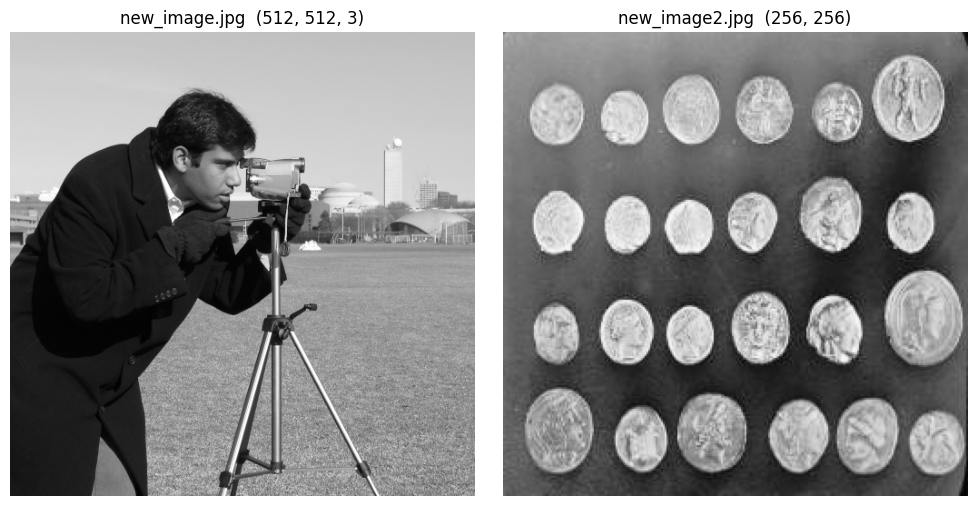

In [51]:
# Read the saved files back to confirm they are valid images
check1 = cv2.imread('output/new_image.jpg')
check2 = Image.open('output/new_image2.jpg')

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(cv2.cvtColor(check1, cv2.COLOR_BGR2RGB))
ax[0].set_title(f"new_image.jpg  {check1.shape}");  ax[0].axis('off')
ax[1].imshow(check2, cmap=cm.Greys_r)
ax[1].set_title(f"new_image2.jpg  {check2.size}");  ax[1].axis('off')
plt.tight_layout()
plt.show()

---
## Task 4 — Display the image as an array

This is the core idea of the whole lab: **an image is a grid of numbers**.
Each number is the intensity of one pixel, stored as `uint8` (an integer from 0 to 255,
where 0 is black and 255 is white).

In [52]:
# The OpenCV image is already a NumPy array
print("shape :", img.shape)      # (height, width, channels)
print("dtype :", img.dtype)
print("size  :", img.size, "values")
print()
print(img)

shape : (512, 512, 3)
dtype : uint8
size  : 786432 values

[[[200 200 200]
  [200 200 200]
  [200 200 200]
  ...
  [189 189 189]
  [190 190 190]
  [190 190 190]]

 [[200 200 200]
  [199 199 199]
  [199 199 199]
  ...
  [190 190 190]
  [190 190 190]
  [190 190 190]]

 [[199 199 199]
  [199 199 199]
  [199 199 199]
  ...
  [190 190 190]
  [190 190 190]
  [190 190 190]]

 ...

 [[ 25  25  25]
  [ 25  25  25]
  [ 27  27  27]
  ...
  [139 139 139]
  [122 122 122]
  [147 147 147]]

 [[ 25  25  25]
  [ 25  25  25]
  [ 26  26  26]
  ...
  [158 158 158]
  [141 141 141]
  [168 168 168]]

 [[ 25  25  25]
  [ 25  25  25]
  [ 27  27  27]
  ...
  [151 151 151]
  [152 152 152]
  [149 149 149]]]


In [53]:
# The PIL image must be converted first
img_array = np.array(img2)

print("shape :", img_array.shape)   # 2-D -> grayscale, no channel axis
print("dtype :", img_array.dtype)
print("min   :", img_array.min(), " max:", img_array.max())
print()
print(img_array)

shape : (256, 256)
dtype : uint8
min   : 4  max: 240

[[ 70 132 132 ...  18  11   9]
 [113 145 144 ...  37   9   7]
 [132 139 143 ...  61   5   7]
 ...
 [ 82  74  69 ...   9   6   6]
 [ 85  76  71 ...   8   6   7]
 [ 88  71  64 ...   6   6   8]]


### 4.1 Reading the numbers by eye

A small corner of the array printed as a table, next to the same corner drawn as pixels.
This makes the number-to-pixel correspondence concrete.

Top-left 8x8 patch of pixel values:
[[ 70 132 132 133 137 134 132 130]
 [113 145 144 135 135 134 132 131]
 [132 139 143 134 136 133 131 132]
 [132 134 135 130 135 132 130 132]
 [130 136 131 131 133 130 130 132]
 [128 132 130 134 131 130 129 131]
 [131 132 131 134 129 130 129 130]
 [129 134 131 129 129 130 128 128]]


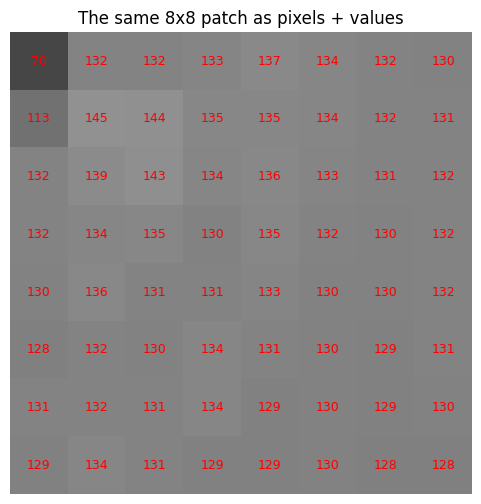

In [54]:
patch = img_array[0:8, 0:8]
print("Top-left 8x8 patch of pixel values:")
print(patch)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(patch, cmap='gray', vmin=0, vmax=255)
for i in range(patch.shape[0]):
    for j in range(patch.shape[1]):
        ax.text(j, i, patch[i, j], ha='center', va='center',
                color='red', fontsize=9)
ax.set_title("The same 8x8 patch as pixels + values")
ax.axis('off')
plt.show()

---
## Task 5 — Assessment: NumPy operations on the image array

> *"The student will be asked to perform different operations on the array using the NumPy library."*

Every operation below uses **only NumPy** — no image-processing function is called.
This shows that standard array operations are already image-processing operations.

### 5.1 Basic statistics of the image

In [55]:
gray = img_array   # 2-D uint8 array, our working image

print("shape        :", gray.shape)
print("dtype        :", gray.dtype)
print("total pixels :", gray.size)
print("min value    :", gray.min())
print("max value    :", gray.max())
print("mean         :", round(float(gray.mean()), 2))
print("median       :", float(np.median(gray)))
print("std deviation:", round(float(gray.std()), 2))

shape        : (256, 256)
dtype        : uint8
total pixels : 65536
min value    : 4
max value    : 240
mean         : 96.86
median       : 87.0
std deviation: 51.81


### 5.2 Cropping — slicing

`gray[row_start:row_end, col_start:col_end]` selects a rectangular region.

cropped shape: (150, 150)


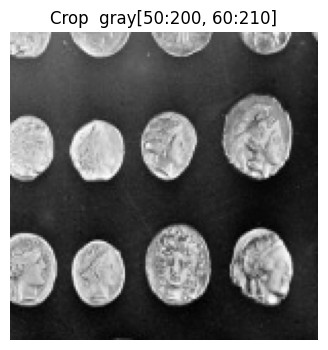

In [56]:
crop = gray[50:200, 60:210]
print("cropped shape:", crop.shape)

plt.figure(figsize=(4, 4))
plt.imshow(crop, cmap='gray')
plt.title("Crop  gray[50:200, 60:210]")
plt.axis('off')
plt.show()

### 5.3 Flipping and transposing — negative steps and `.T`

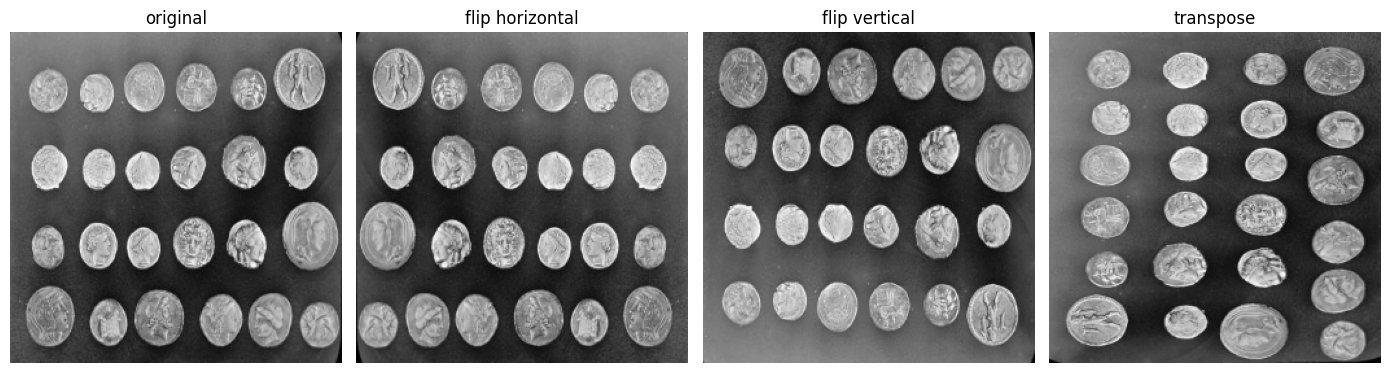

In [57]:
flip_h = gray[:, ::-1]        # reverse the columns  -> horizontal flip
flip_v = gray[::-1, :]        # reverse the rows     -> vertical flip
trans  = gray.T               # transpose            -> diagonal mirror

fig, ax = plt.subplots(1, 4, figsize=(14, 4))
for a_, im_, t_ in zip(ax, [gray, flip_h, flip_v, trans],
                       ["original", "flip horizontal", "flip vertical", "transpose"]):
    a_.imshow(im_, cmap='gray'); a_.set_title(t_); a_.axis('off')
plt.tight_layout()
plt.show()

### 5.4 Brightness and negative — arithmetic

Adding a constant makes the image brighter. `np.clip` is required because `uint8` wraps around
at 255: without clipping, a value of 260 becomes 4 and bright areas turn black.

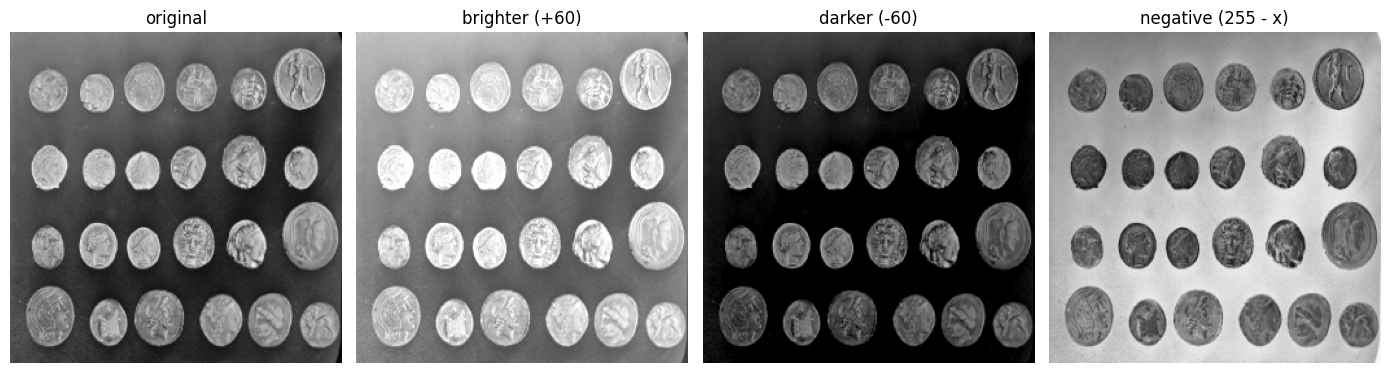

original mean: 96.9 | brighter mean: 156.5 | darker mean: 42.7


In [58]:
bright = np.clip(gray.astype(np.int16) + 60, 0, 255).astype(np.uint8)
dark   = np.clip(gray.astype(np.int16) - 60, 0, 255).astype(np.uint8)
neg    = 255 - gray                     # photographic negative

fig, ax = plt.subplots(1, 4, figsize=(14, 4))
for a_, im_, t_ in zip(ax, [gray, bright, dark, neg],
                       ["original", "brighter (+60)", "darker (-60)", "negative (255 - x)"]):
    a_.imshow(im_, cmap='gray', vmin=0, vmax=255); a_.set_title(t_); a_.axis('off')
plt.tight_layout()
plt.show()

print("original mean:", round(float(gray.mean()), 1),
      "| brighter mean:", round(float(bright.mean()), 1),
      "| darker mean:", round(float(dark.mean()), 1))

### 5.5 Thresholding — boolean indexing

`gray > 128` produces a boolean array of the same shape. This is exactly the
`a[a < 2]` idea from the cheat sheet, applied to an image.

mask dtype       : bool
white pixels     : 19388
fraction white   : 0.296
unique values    : [  0 255]


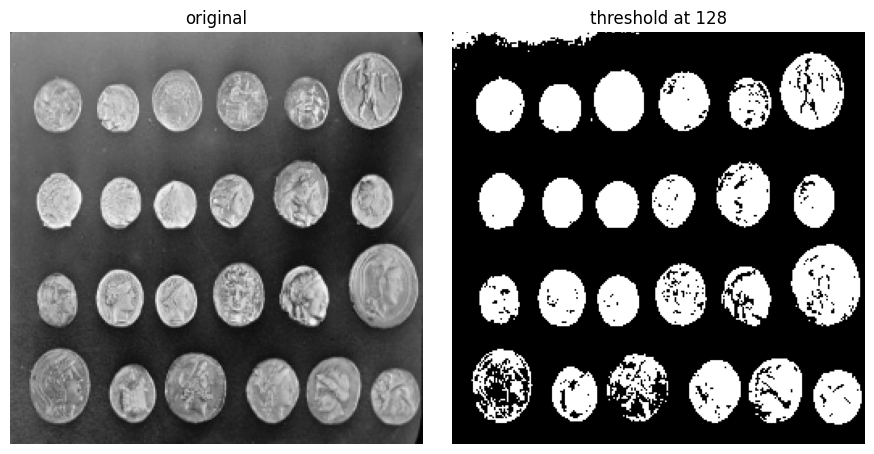

In [59]:
mask   = gray > 128                                  # boolean array
binary = np.where(mask, 255, 0).astype(np.uint8)     # True -> white, False -> black

print("mask dtype       :", mask.dtype)
print("white pixels     :", int(mask.sum()))
print("fraction white   :", round(float(mask.mean()), 3))
print("unique values    :", np.unique(binary))

fig, ax = plt.subplots(1, 2, figsize=(9, 4.5))
ax[0].imshow(gray, cmap='gray');   ax[0].set_title("original");            ax[0].axis('off')
ax[1].imshow(binary, cmap='gray'); ax[1].set_title("threshold at 128");    ax[1].axis('off')
plt.tight_layout()
plt.show()

### 5.6 Downsampling — step slicing

`gray[::4, ::4]` keeps every 4th row and every 4th column, shrinking the image 4x
in each direction without calling any resize function.

step 1: shape (256, 256)
step 2: shape (128, 128)
step 4: shape (64, 64)
step 8: shape (32, 32)


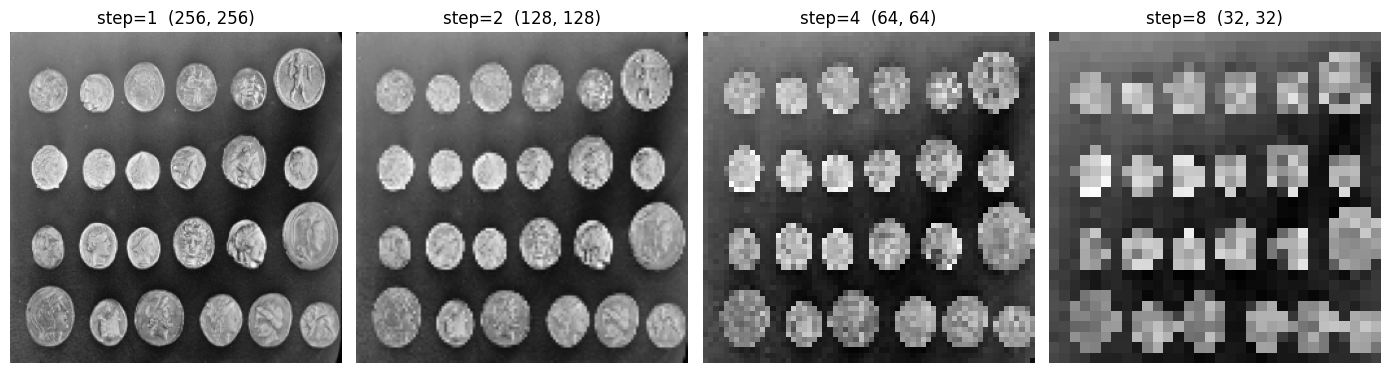

In [60]:
for step in [1, 2, 4, 8]:
    print(f"step {step}: shape {gray[::step, ::step].shape}")

fig, ax = plt.subplots(1, 4, figsize=(14, 4))
for a_, s_ in zip(ax, [1, 2, 4, 8]):
    small = gray[::s_, ::s_]
    a_.imshow(small, cmap='gray'); a_.set_title(f"step={s_}  {small.shape}"); a_.axis('off')
plt.tight_layout()
plt.show()

### 5.7 Splitting and stacking — `vsplit`, `vstack`, `hstack`

top: (128, 256) | bottom: (128, 256)
swapped: (256, 256) | side_by_side: (256, 512)


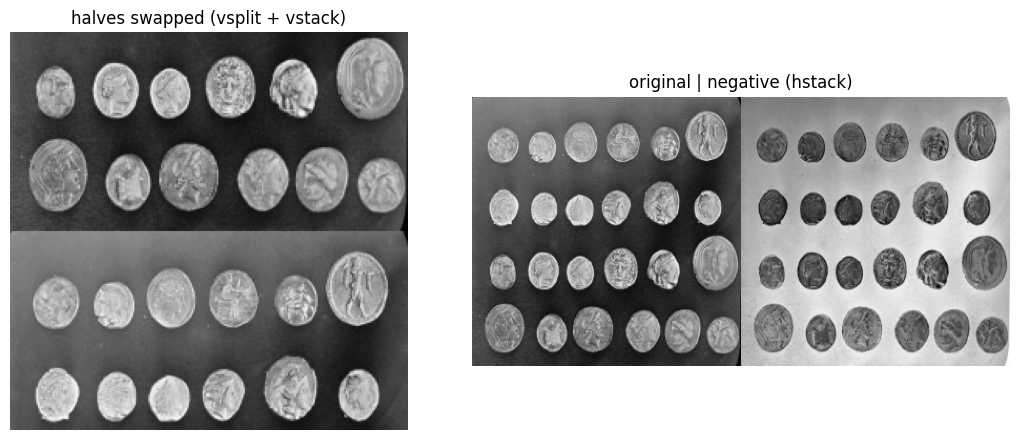

In [61]:
top, bottom = np.vsplit(gray, 2)          # split into two halves
swapped     = np.vstack((bottom, top))    # put the bottom half on top
side_by_side = np.hstack((gray, 255 - gray))

print("top:", top.shape, "| bottom:", bottom.shape)
print("swapped:", swapped.shape, "| side_by_side:", side_by_side.shape)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
ax[0].imshow(swapped, cmap='gray');      ax[0].set_title("halves swapped (vsplit + vstack)"); ax[0].axis('off')
ax[1].imshow(side_by_side, cmap='gray'); ax[1].set_title("original | negative (hstack)");     ax[1].axis('off')
plt.tight_layout()
plt.show()

### 5.8 Building a colour image — `np.dstack`

Stacking three 2-D arrays along a third axis creates an (H, W, 3) RGB array.
Here the red channel is the image, green is empty, and blue is the negative.

stacked shape: (256, 256, 3) | ndim: 3


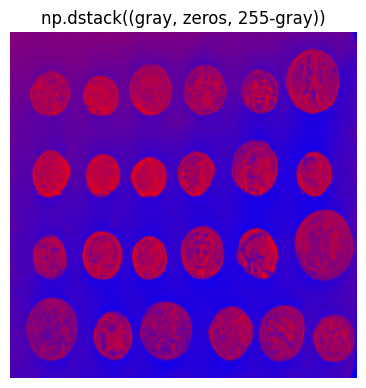

In [62]:
rgb = np.dstack((gray, np.zeros_like(gray), 255 - gray))
print("stacked shape:", rgb.shape, "| ndim:", rgb.ndim)

plt.figure(figsize=(4.5, 4.5))
plt.imshow(rgb)
plt.title("np.dstack((gray, zeros, 255-gray))")
plt.axis('off')
plt.show()

### 5.9 Histogram — `np.histogram`

The histogram counts how many pixels fall into each intensity range. It summarises the
brightness distribution of the whole image in a single plot.

[   0.0 -   15.9] :     50 pixels
[  15.9 -   31.9] :   3757 pixels
[  31.9 -   47.8] :  10411 pixels
[  47.8 -   63.8] :   8709 pixels
[  63.8 -   79.7] :   6944 pixels
[  79.7 -   95.6] :   6320 pixels
[  95.6 -  111.6] :   4766 pixels
[ 111.6 -  127.5] :   4880 pixels
[ 127.5 -  143.4] :   4348 pixels
[ 143.4 -  159.4] :   4565 pixels
[ 159.4 -  175.3] :   4688 pixels
[ 175.3 -  191.2] :   3611 pixels
[ 191.2 -  207.2] :   1779 pixels
[ 207.2 -  223.1] :    585 pixels
[ 223.1 -  239.1] :    122 pixels
[ 239.1 -  255.0] :      1 pixels


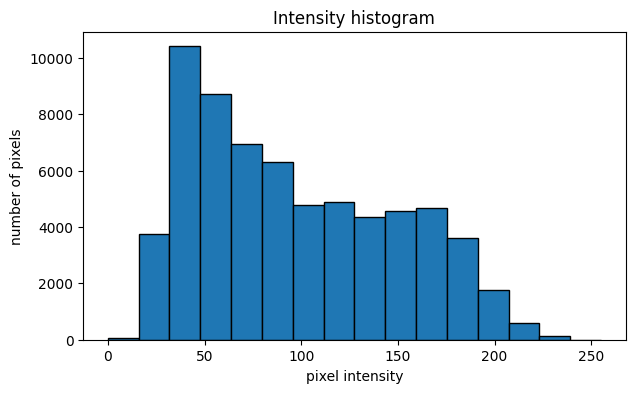

In [63]:
hist, bin_edges = np.histogram(gray, bins=16, range=(0, 255))
for count, lo, hi in zip(hist, bin_edges[:-1], bin_edges[1:]):
    print(f"[{lo:6.1f} - {hi:6.1f}] : {count:6d} pixels")

plt.figure(figsize=(7, 4))
plt.bar(bin_edges[:-1], hist, width=np.diff(bin_edges), align='edge', edgecolor='black')
plt.xlabel("pixel intensity")
plt.ylabel("number of pixels")
plt.title("Intensity histogram")
plt.show()

### 5.10 Masking with a computed condition

Pixels brighter than the mean are kept; everything else is set to 0. This combines
boolean indexing with `.copy()` — note that `.copy()` is required, otherwise we would
modify the original array.

original mean unchanged: 96.86
pixels kept            : 29032


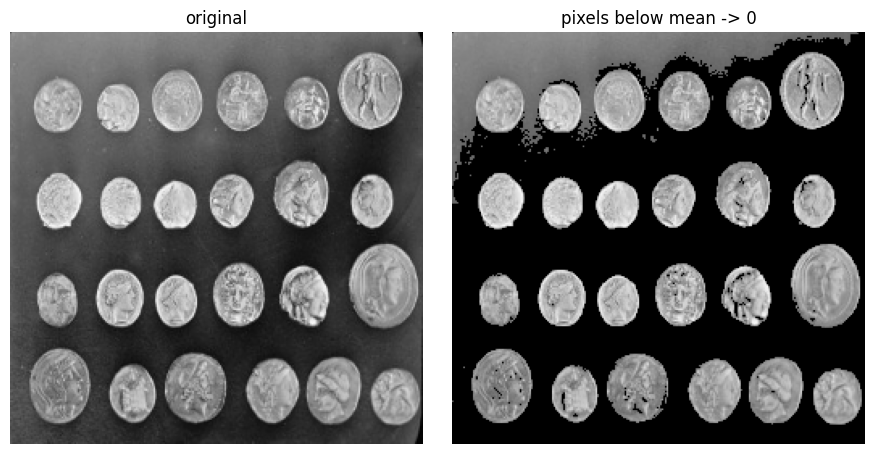

In [64]:
masked = gray.copy()             # deep copy, the original stays intact
masked[gray < gray.mean()] = 0   # assign through a boolean mask

print("original mean unchanged:", round(float(gray.mean()), 2))
print("pixels kept            :", int((masked > 0).sum()))

fig, ax = plt.subplots(1, 2, figsize=(9, 4.5))
ax[0].imshow(gray, cmap='gray');   ax[0].set_title("original");                 ax[0].axis('off')
ax[1].imshow(masked, cmap='gray'); ax[1].set_title("pixels below mean -> 0");   ax[1].axis('off')
plt.tight_layout()
plt.show()

### 5.11 Summary figure

All the operations of Task 5 in one view.

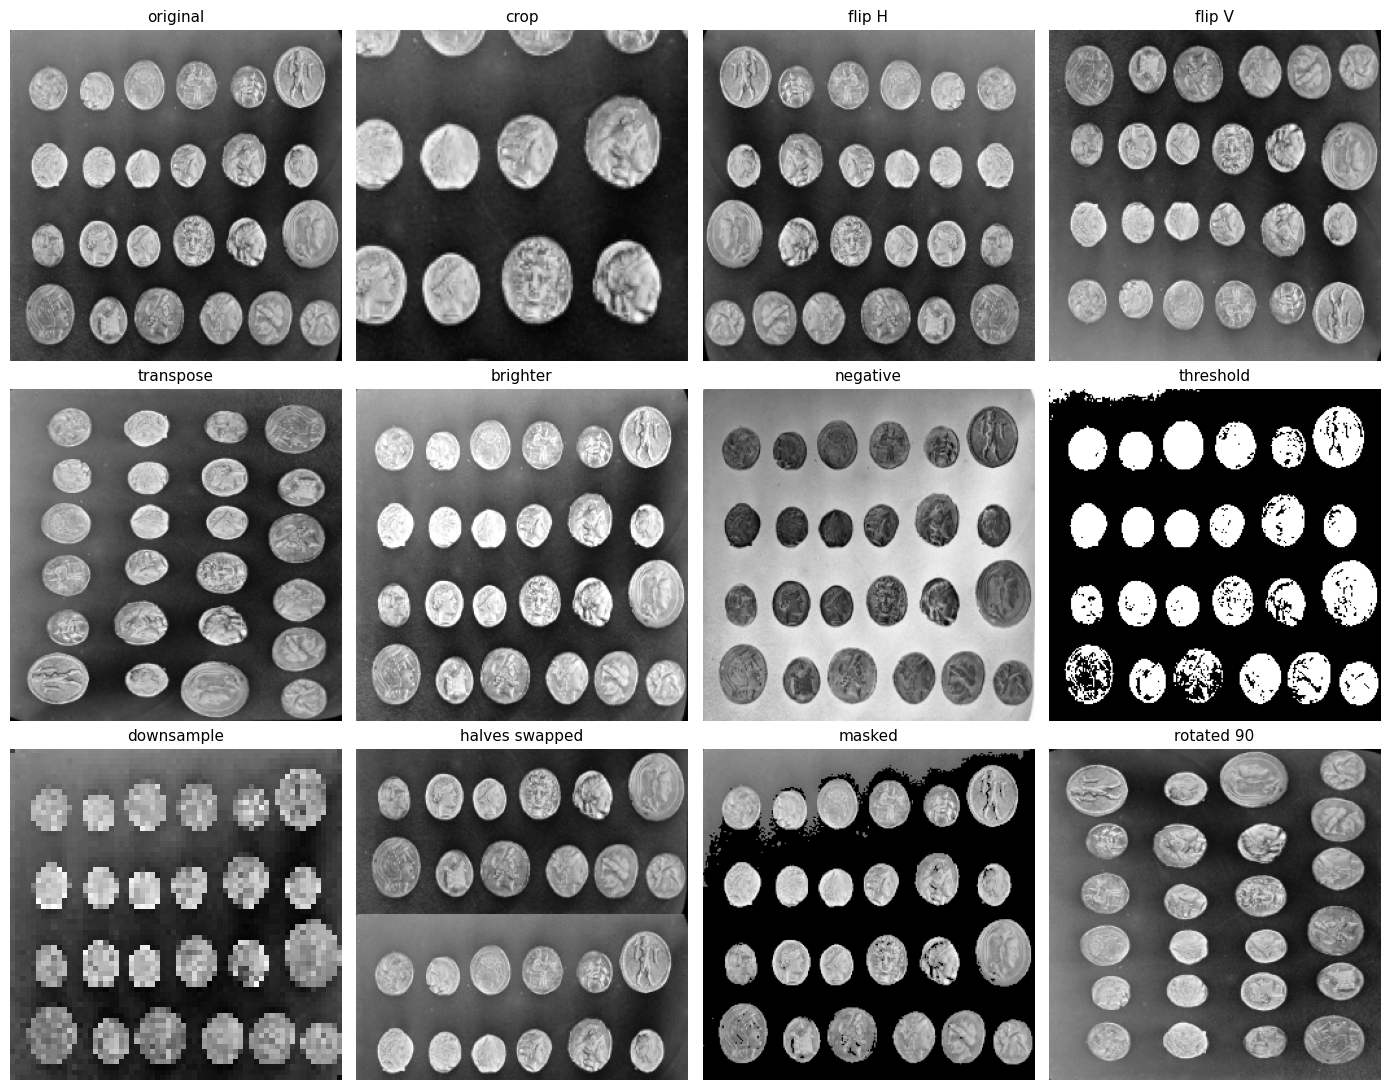

Saved: output/summary.png


In [65]:
ops = [(gray, "original"), (crop, "crop"), (flip_h, "flip H"), (flip_v, "flip V"),
       (trans, "transpose"), (bright, "brighter"), (neg, "negative"),
       (binary, "threshold"), (gray[::4, ::4], "downsample"), (swapped, "halves swapped"),
       (masked, "masked"), (gray.T[::-1], "rotated 90")]

fig, ax = plt.subplots(3, 4, figsize=(14, 11))
for a_, (im_, t_) in zip(ax.flat, ops):
    a_.imshow(im_, cmap='gray'); a_.set_title(t_, fontsize=11); a_.axis('off')
plt.tight_layout()
plt.savefig('output/summary.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: output/summary.png")

---
## Conclusion

**Outcome #1 — how digital images are represented and manipulated in a computer:**

1. A digital image is stored as a **NumPy array of integers**. A grayscale image is 2-D with
   shape `(height, width)`; a colour image is 3-D with shape `(height, width, 3)`.
2. Each value is a **pixel intensity** in `uint8` format, ranging from 0 (black) to 255 (white).
   The `uint8` type is why `np.clip` is needed for arithmetic: values above 255 wrap around.
3. **Loading** an image is just filling that array — `cv2.imread()` returns the array directly
   in **BGR** order, while `Image.open()` returns a PIL object that `np.array()` converts to
   **RGB**. Mixing the two orders is the most common source of wrong colours.
4. **Manipulating** an image is ordinary NumPy array manipulation. Slicing crops and
   downsamples, negative steps flip, `.T` transposes, arithmetic changes brightness,
   `255 - x` inverts, boolean indexing thresholds and masks, and `vstack` / `hstack` /
   `dstack` recombine regions and channels.
5. Because these are array operations rather than image-specific functions, they run on the
   whole image at once (vectorised) instead of pixel by pixel with Python loops.

---

### References
- NumPy Basics cheat sheet (course resources)
- Python Basics cheat sheet (course resources)
- scikit-image sample data: https://scikit-image.org/docs/stable/auto_examples/data/plot_general.html
- OpenCV documentation: https://docs.opencv.org/
- Pillow documentation: https://pillow.readthedocs.io/